# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 32     |  |
| :-------------|:-------------|
| Zenn Idu| 6225497 |
| Sarah Ilyas|6223265 |
| Raoul Staas| 3529003 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="Schets1.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

def vlakkeplaat(epsilon_r, A, d):
    epsilon0 = 8.854e-12  
    C =  (epsilon0 * epsilon_r * A) / d
    return C

def voltagecondensator(Q, C):
    V = Q / C
    return V


    # 1.3275 e-10
    # 1.77010e-10
    # 2.655e-10



In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

epsilon_lucht = 1.0006

C = vlakkeplaat(epsilon_lucht, 0.01, 0.001)


print(f"Berekende capaciteit plaatcondensator groep 32 is {C*1e12:.1f} pF")

V = voltagecondensator(1e-9, C)

print(f"Berekende voltage plaatcondensator groep 32 is {V:.1f} V")




Berekende capaciteit plaatcondensator groep 32 is 88.6 pF
Berekende voltage plaatcondensator groep 32 is 11.3 V


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](Schets2.jpg)
![scope meting 2](Schets3.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug.

| Namen    | Berekende capaciteit | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit |
|----------|----------------------|------------------|------------------|--------------------|
| Groep 1  | 88.6 pF              | 11.3 V                | 1.56 V           | 155 pF             |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](Schets4.jpg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
Zie eerste schets van opdracht 2

[132.81 177.08 265.62]
a = 66.40 pF/kg
b = 125.43 pF


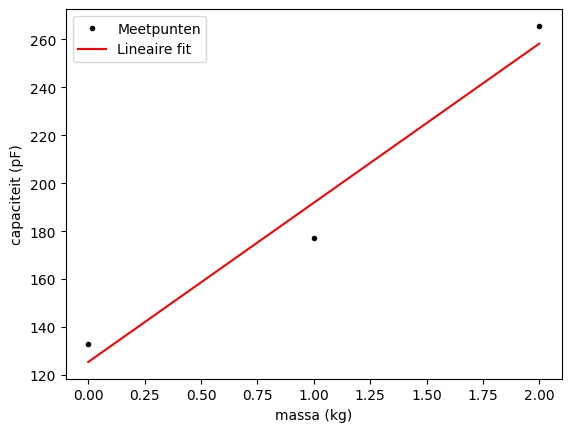

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

# Meetdata
m = np.array([0, 1, 2]) #Meetgebied waar we willen zitten
uitwijking2kg=0.0005#Gok voor ontwerpgrafiek niet een meting, het foam is 1 mm dik, dus dat deze met 0.5 mm induwt bij 2kg is een redelijke gok.
veerk=(m[2]*9.81)/uitwijking2kg #Veerconstante bepalen uit gok, afgeleid uit F=ku => F/u=k
dontwerp= 0.001-(m*9.81)/veerk#hier wordt de afstand tussen de condensatoren voor de ontwerppunten bepaald
Aontwerp=0.1*0.1 #oppervlakte
epsilon_foam=1.5

C= vlakkeplaat(epsilon_foam,Aontwerp,dontwerp)*1e12# De Capaciteiten in pF
print(C)


# lineaire functie als fit, want klein meetbereik (goede benadering => Taylorreeks)
def lineair(m, a, b):
    return a * m + b

# Curve fit
popt, pcov = curve_fit(lineair, m, C)
a, b = popt

print(f"a = {a:.2f} pF/kg")
print(f"b = {b:.2f} pF")

# Plot
m_test = np.linspace(m.min(), m.max(), 100)

plt.figure()
plt.plot(m, C, 'k.', label='Meetpunten')
plt.plot(m_test, lineair(m_test, *popt), 'r-', label='Lineaire fit')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.show()

# Natuurkundige onderbouwing van onze ontwerpgrafiek:
Dit is het theoretische verband van onze sensor. Echter is dit niet een fijne functie om mee te fitten omdat: de constanten k en epsilon_r niet goed nauwkeurig te bepalen zijn, 
en de aanname van constante epsilon_r niet helemaal lijkt te kloppen in de praktijk. Omdat er op een relatief klein gebied wordt gemeten is er gekozen voor een lineaire fit, 
zo kan de sensor op ons gewenste meetgebied toch goed geijkt worden. 

![drie schetsen](1000100519.jpg)

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 133pF |0.67V |
| gemiddelde capaciteit| 177pF |0.88V |
| maximale capaciteit| 266 pF |1.32V |

## Opdracht 6: Foto's werkende opstelling.

![Werkende opstelling](Schets2.jpg)


#### Voeg hier de foto's van je sensoren in actie in.
![Sensor in actie](Schets5.jpg))
![Sensor in actie](Schets6.jpg)

## Opdracht 7: Plot de kalibratiegrafiek.

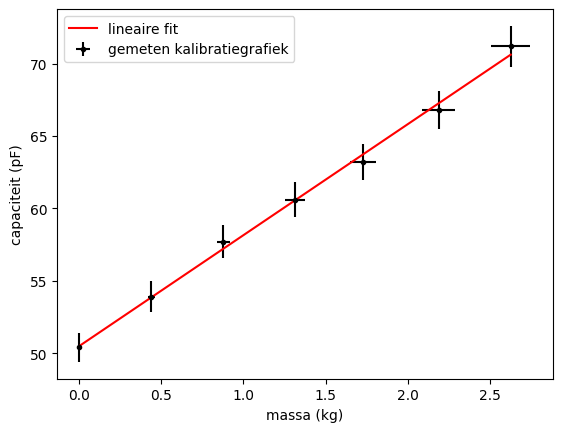

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

m = np.array([0, 437.89, 875.99, 1315.85, 1730.61, 2190.23, 2628.70])   /1000 #kg
U_m=m*(20/437.89)
C = np.array([50.4, 53.9, 57.7, 60.6, 63.2, 66.8, 71.2]) #pF
U_C=C*(1/50.4)


popt, pcov = curve_fit(lineair, m, C)

m_test = np.linspace(m.min(), m.max(), 100)
plt.figure()
#plt.plot(m, C, 'k.', label='gemeten kalibratiegrafiek')
plt.errorbar(x=m, y=C, xerr=U_m, yerr=U_C, fmt='k.', label='gemeten kalibratiegrafiek')
plt.plot(m_test, lineair(m_test, *popt), 'r-', label='lineaire fit')
plt.legend()
plt.xlabel('massa (kg)')        
plt.ylabel('capaciteit (pF)')
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

*  Het moet een groter bereik van massa kunnen meten
* De spons vervangen door een materiaal waarvan we de veerconstante meten en dat de veerconstatne niet verandert naarmate er lucht bij komt

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](Schets2.jpg)

In [5]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij

#Wij hebben geen iteratie omdat onze eerste versie al voldeed aan onze eisen

## Opdracht 10: Vul hieronder de conclusie in.

Vul hier de conclusie in

Er is gekozen voor een lineair verband, omdat het onderzochte meetbereik zeer klein is. Binnen zo’n beperkt interval kan een niet-lineaire functie lokaal goed benaderd worden als lineair. Dit is onder andere te verklaren met behulp van de Taylorreeks, die stelt dat een functie in een klein gebied rond een punt kan worden benaderd door de eerste orde term, en dus als lineair kan worden beschouwd.

De sensor blijkt geschikt te zijn om het beoogde fenomeen daadwerkelijk te meten. Er was geen iteratieve aanpassing van het ontwerp nodig. Bovendien is er geen significant verschil waarneembaar tussen de ontwerpgrafiek en de kalibratiegrafiek. Dit bevestigt dat de vlakke-plaatformule een goede benadering vormt voor onze specifieke sensorconfiguratie.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

<img src="Schets1.jpg" alt="schets student 1" width="400"/>

![drie schetsen](Schets4.jpg)

[132.81 177.08 265.62]
a = 66.40 pF/kg
b = 125.43 pF


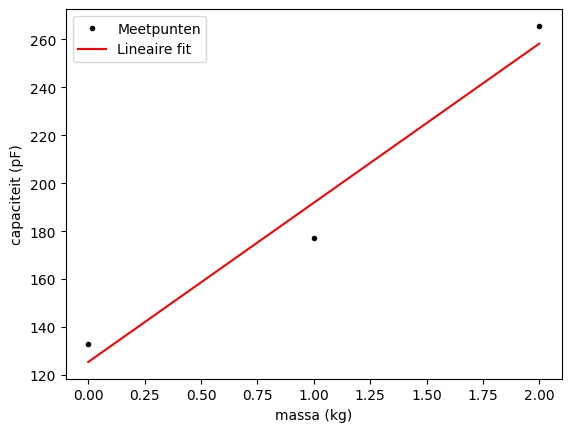

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

# Meetdata
m = np.array([0, 1, 2]) #Meetgebied waar we willen zitten
uitwijking2kg=0.0005#Gok voor ontwerpgrafiek niet een meting, het foam is 1 mm dik, dus dat deze met 0.5 mm induwt bij 2kg is een redelijke gok.
veerk=(m[2]*9.81)/uitwijking2kg #Veerconstante bepalen uit gok, afgeleid uit F=ku => F/u=k
dontwerp= 0.001-(m*9.81)/veerk#hier wordt de afstand tussen de condensatoren voor de ontwerppunten bepaald
Aontwerp=0.1*0.1 #oppervlakte
epsilon_foam=1.5

C= vlakkeplaat(epsilon_foam,Aontwerp,dontwerp)*1e12# De Capaciteiten in pF
print(C)


# lineaire functie als fit, want klein meetbereik (goede benadering => Taylorreeks)
def lineair(m, a, b):
    return a * m + b

# Curve fit
popt, pcov = curve_fit(lineair, m, C)
a, b = popt

print(f"a = {a:.2f} pF/kg")
print(f"b = {b:.2f} pF")

# Plot
m_test = np.linspace(m.min(), m.max(), 100)

plt.figure()
plt.plot(m, C, 'k.', label='Meetpunten')
plt.plot(m_test, lineair(m_test, *popt), 'r-', label='Lineaire fit')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.show()

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 133pF |0.67V |
| gemiddelde capaciteit| 177pF |0.88V |
| maximale capaciteit| 266 pF |1.32V |

[132.81 177.08 265.62]
a = 66.40 pF/kg
b = 125.43 pF


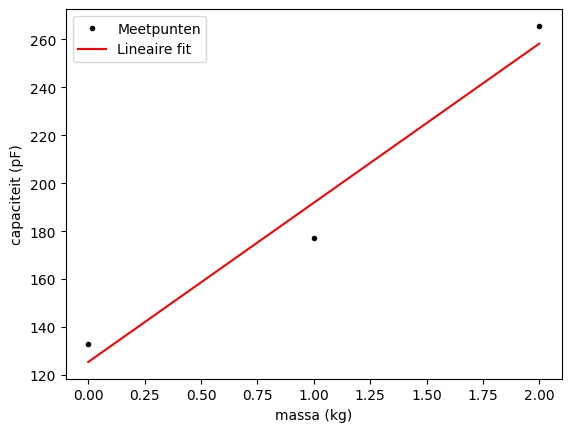

In [7]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

# Meetdata
m = np.array([0, 1, 2]) #Meetgebied waar we willen zitten
uitwijking2kg=0.0005#Gok voor ontwerpgrafiek niet een meting, het foam is 1 mm dik, dus dat deze met 0.5 mm induwt bij 2kg is een redelijke gok.
veerk=(m[2]*9.81)/uitwijking2kg #Veerconstante bepalen uit gok, afgeleid uit F=ku => F/u=k
dontwerp= 0.001-(m*9.81)/veerk#hier wordt de afstand tussen de condensatoren voor de ontwerppunten bepaald
Aontwerp=0.1*0.1 #oppervlakte
epsilon_foam=1.5

C= vlakkeplaat(epsilon_foam,Aontwerp,dontwerp)*1e12# De Capaciteiten in pF
print(C)


# lineaire functie als fit, want klein meetbereik (goede benadering => Taylorreeks)
def lineair(m, a, b):
    return a * m + b

# Curve fit
popt, pcov = curve_fit(lineair, m, C)
a, b = popt

print(f"a = {a:.2f} pF/kg")
print(f"b = {b:.2f} pF")

# Plot
m_test = np.linspace(m.min(), m.max(), 100)

plt.figure()
plt.plot(m, C, 'k.', label='Meetpunten')
plt.plot(m_test, lineair(m_test, *popt), 'r-', label='Lineaire fit')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.show()

![scope meting 1](Schets2.jpg)
![scope meting 2](Schets3.jpg)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

[132.81 177.08 265.62]
a = 66.40 pF/kg
b = 125.43 pF


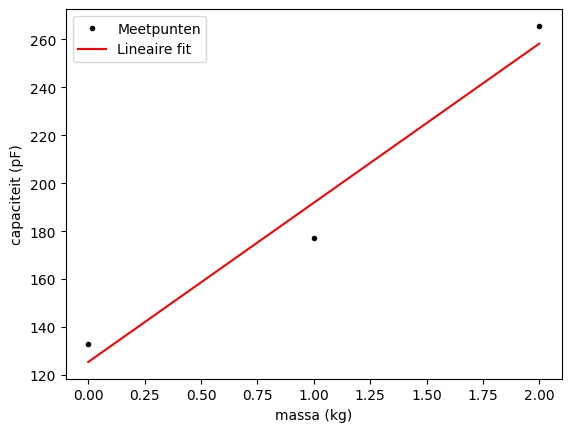

In [8]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit

# Meetdata
m = np.array([0, 1, 2]) #Meetgebied waar we willen zitten
uitwijking2kg=0.0005#Gok voor ontwerpgrafiek niet een meting, het foam is 1 mm dik, dus dat deze met 0.5 mm induwt bij 2kg is een redelijke gok.
veerk=(m[2]*9.81)/uitwijking2kg #Veerconstante bepalen uit gok, afgeleid uit F=ku => F/u=k
dontwerp= 0.001-(m*9.81)/veerk#hier wordt de afstand tussen de condensatoren voor de ontwerppunten bepaald
Aontwerp=0.1*0.1 #oppervlakte
epsilon_foam=1.5

C= vlakkeplaat(epsilon_foam,Aontwerp,dontwerp)*1e12# De Capaciteiten in pF
print(C)


# lineaire functie als fit, want klein meetbereik (goede benadering => Taylorreeks)
def lineair(m, a, b):
    return a * m + b

# Curve fit
popt, pcov = curve_fit(lineair, m, C)
a, b = popt

print(f"a = {a:.2f} pF/kg")
print(f"b = {b:.2f} pF")

# Plot
m_test = np.linspace(m.min(), m.max(), 100)

plt.figure()
plt.plot(m, C, 'k.', label='Meetpunten')
plt.plot(m_test, lineair(m_test, *popt), 'r-', label='Lineaire fit')
plt.xlabel('massa (kg)')
plt.ylabel('capaciteit (pF)')
plt.legend()
plt.show()

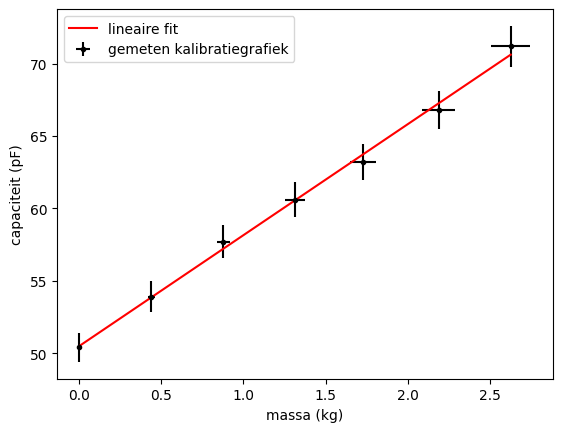

In [9]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.

m = np.array([0, 437.89, 875.99, 1315.85, 1730.61, 2190.23, 2628.70])   /1000 #kg
U_m=m*(20/437.89)
C = np.array([50.4, 53.9, 57.7, 60.6, 63.2, 66.8, 71.2]) #pF
U_C=C*(1/50.4)


popt, pcov = curve_fit(lineair, m, C)

m_test = np.linspace(m.min(), m.max(), 100)
plt.figure()
#plt.plot(m, C, 'k.', label='gemeten kalibratiegrafiek')
plt.errorbar(x=m, y=C, xerr=U_m, yerr=U_C, fmt='k.', label='gemeten kalibratiegrafiek')
plt.plot(m_test, lineair(m_test, *popt), 'r-', label='lineaire fit')
plt.legend()
plt.xlabel('massa (kg)')        
plt.ylabel('capaciteit (pF)')
plt.show()